In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#import seaborn as sns

#we want our plots to appear inside the notebook
%matplotlib inline

#models from scikit learn
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

#Model evaluations
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay


In [2]:
np.__version__


'2.3.5'

## load data

In [3]:
df = pd.read_csv("heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
df.shape

(1025, 14)

In [5]:
df["target"].value_counts()

target
1    526
0    499
Name: count, dtype: int64

<Axes: xlabel='target'>

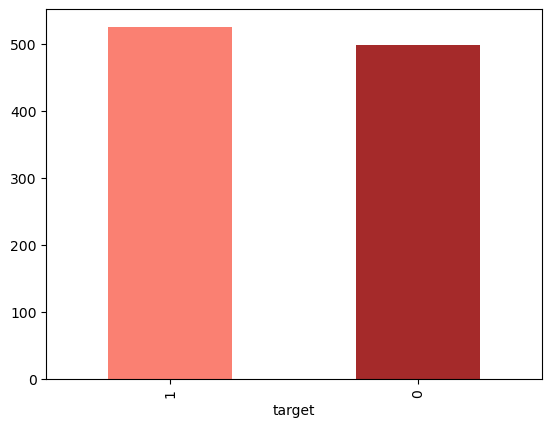

In [6]:
df["target"].value_counts().plot(kind="bar", color= ["salmon", "brown"])

In [7]:
#are they any missing value
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [8]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


<Axes: xlabel='target'>

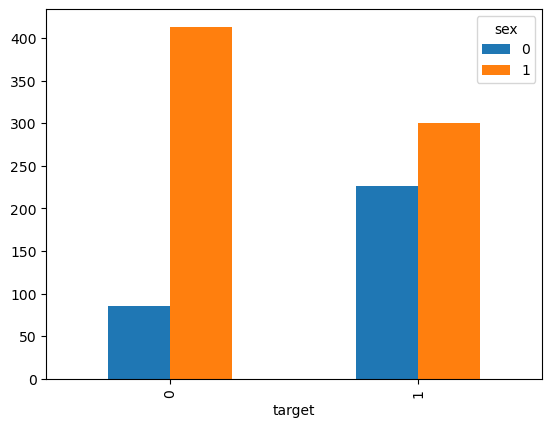

In [9]:
#compare target colum with sex column
pd.crosstab(df.target, df.sex).plot(kind="bar")

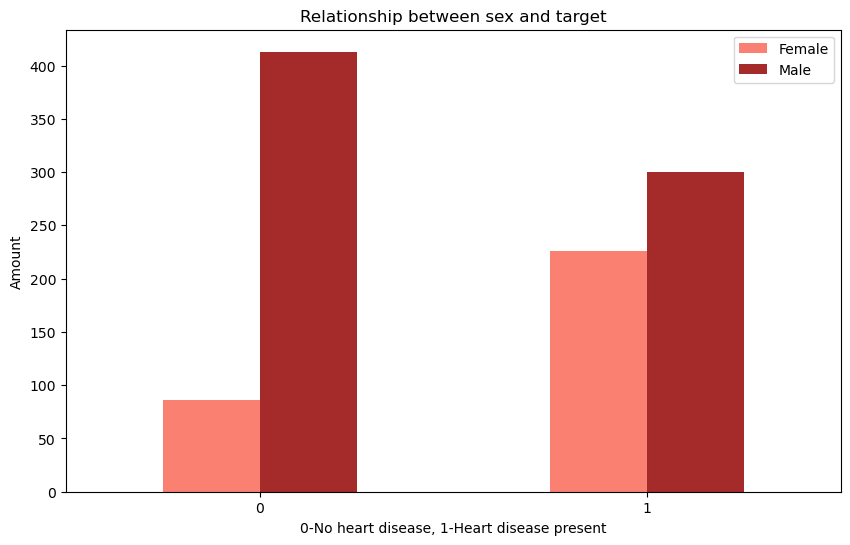

In [10]:
pd.crosstab(df.target, df.sex).plot(kind="bar",
                                    figsize=[10, 6], 
                                    color = ["salmon", "brown"])

plt.title("Relationship between sex and target")
plt.xlabel("0-No heart disease, 1-Heart disease present")
plt.ylabel("Amount")
plt.legend(["Female", "Male"])
plt.xticks(rotation=0);

In [11]:
df.thalach.value_counts()

thalach
162    35
160    31
163    29
173    28
152    28
       ..
194     3
185     3
106     3
88      3
113     3
Name: count, Length: 91, dtype: int64

## Age vs Max heart disease

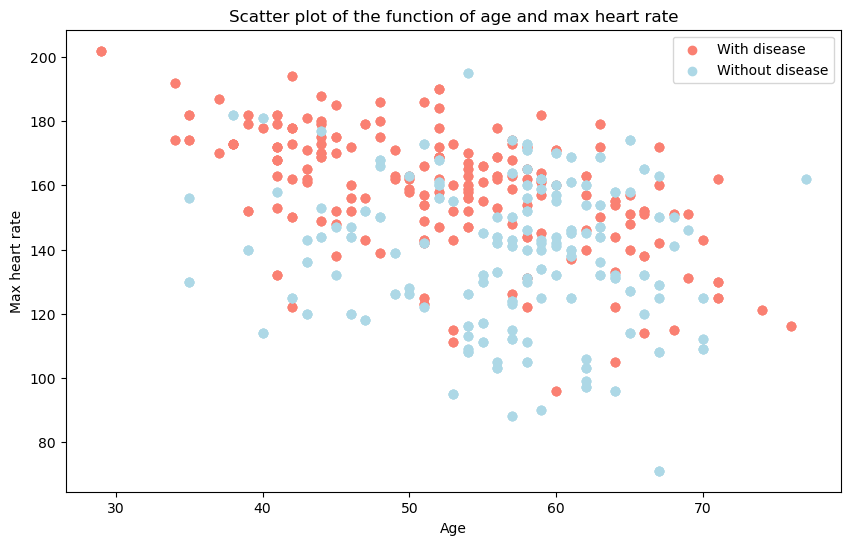

In [12]:
#create another figure
plt.figure(figsize=(10,6))

#scatter with positive example
plt.scatter(df.age[df.target==1],
            df.thalach[df.target==1],
            color="salmon")

#scatter with negative example
plt.scatter(df.age[df.target==0],
            df.thalach[df.target==0],
            color="lightblue")

plt.title("Scatter plot of the function of age and max heart rate")
plt.xlabel("Age")
plt.ylabel("Max heart rate")
plt.legend(["With disease", "Without disease"])

<Axes: ylabel='Frequency'>

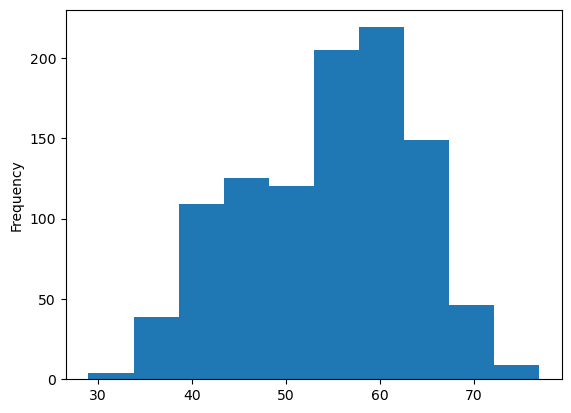

In [13]:
#check the distribution of age column
df.age.plot.hist()

In [14]:
pd.crosstab(df.cp, df.target)

target,0,1
cp,,
0,375,122
1,33,134
2,65,219
3,26,51


(array([0, 1, 2, 3]),
 [Text(0, 0, '0'), Text(1, 0, '1'), Text(2, 0, '2'), Text(3, 0, '3')])

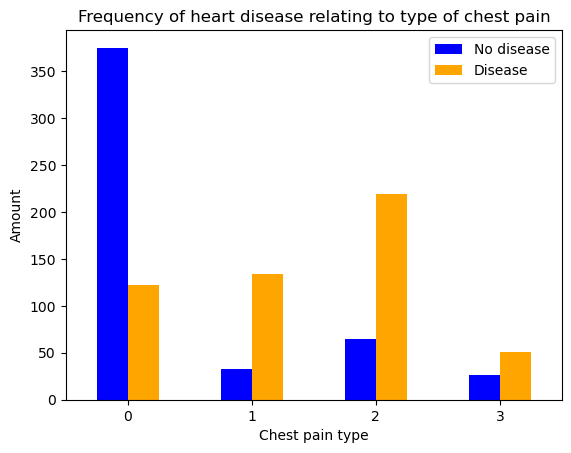

In [15]:
pd.crosstab(df.cp, df.target).plot(kind="bar",
                                   color=["blue", "orange"])

plt.title("Frequency of heart disease relating to type of chest pain")
plt.xlabel("Chest pain type")
plt.ylabel("Amount")
plt.legend(["No disease", "Disease"])
plt.xticks(rotation=0)

In [16]:
import seaborn as sns
df.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.103240,-0.071966,0.271121,0.219823,0.121243,-0.132696,-0.390227,0.088163,0.208137,-0.169105,0.271551,0.072297,-0.229324
sex,-0.103240,1.000000,-0.041119,-0.078974,-0.198258,0.027200,-0.055117,-0.049365,0.139157,0.084687,-0.026666,0.111729,0.198424,-0.279501
cp,-0.071966,-0.041119,1.000000,0.038177,-0.081641,0.079294,0.043581,0.306839,-0.401513,-0.174733,0.131633,-0.176206,-0.163341,0.434854
trestbps,0.271121,-0.078974,0.038177,1.000000,0.127977,0.181767,-0.123794,-0.039264,0.061197,0.187434,-0.120445,0.104554,0.059276,-0.138772
chol,0.219823,-0.198258,-0.081641,0.127977,1.000000,0.026917,-0.147410,-0.021772,0.067382,0.064880,-0.014248,0.074259,0.100244,-0.099966
fbs,0.121243,0.027200,0.079294,0.181767,0.026917,1.000000,-0.104051,-0.008866,0.049261,0.010859,-0.061902,0.137156,-0.042177,-0.041164
restecg,-0.132696,-0.055117,0.043581,-0.123794,-0.147410,-0.104051,1.000000,0.048411,-0.065606,-0.050114,0.086086,-0.078072,-0.020504,0.134468
thalach,-0.390227,-0.049365,0.306839,-0.039264,-0.021772,-0.008866,0.048411,1.000000,-0.380281,-0.349796,0.395308,-0.207888,-0.098068,0.422895
exang,0.088163,0.139157,-0.401513,0.061197,0.067382,0.049261,-0.065606,-0.380281,1.000000,0.310844,-0.267335,0.107849,0.197201,-0.438029
oldpeak,0.208137,0.084687,-0.174733,0.187434,0.064880,0.010859,-0.050114,-0.349796,0.310844,1.000000,-0.575189,0.221816,0.202672,-0.438441


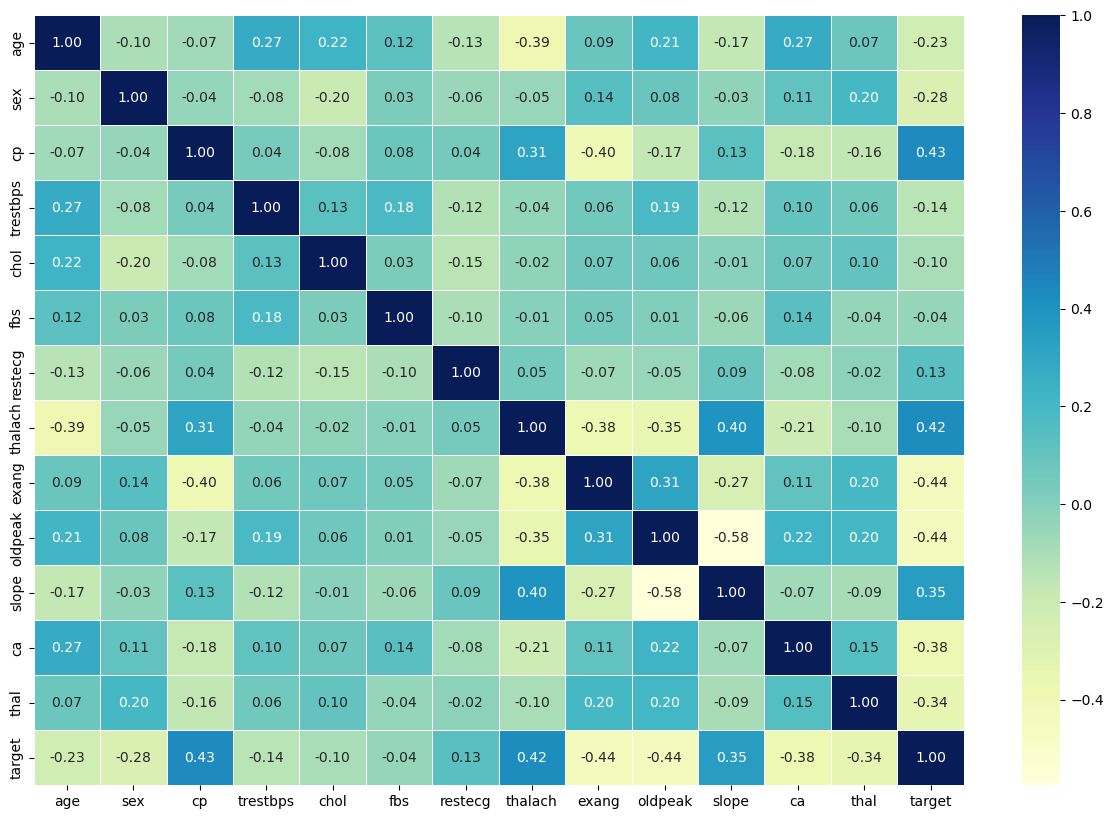

In [17]:
corr_matrix = df.corr()
fig, ax = plt.subplots(figsize=(15,10))
ax = sns.heatmap(corr_matrix,
                 annot=True,
                 linewidths=0.5,
                 fmt=".2f",
                 cmap="YlGnBu")
                 

## 5. Modelling

In [18]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [19]:
#split into X and y
X = df.drop("target", axis=1)
y = df["target"]

np.random.seed(42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


In [20]:
#create a dictionary for the models

models= {"Logistic Regression": LogisticRegression(),
         "KNN": KNeighborsClassifier(),
         "Random Forest": RandomForestClassifier()
        }

#create a function to fit and score models
def fit_and_score(models, X_train, X_test, y_train, y_test):
    np.random.seed(42)
    model_scores= {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        model_scores[name] = model.score(X_test, y_test)

    return model_scores

In [21]:
#run the function

model_scores= fit_and_score(models=models,
              X_train=X_train,
              X_test=X_test,
              y_train=y_train,
              y_test=y_test)
model_scores

C:\Users\DONALD MAMAH\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'Logistic Regression': 0.7853658536585366,
 'KNN': 0.7317073170731707,
 'Random Forest': 0.9853658536585366}

(array([0, 1, 2]),
 [Text(0, 0, 'Logistic Regression'),
  Text(1, 0, 'KNN'),
  Text(2, 0, 'Random Forest')])

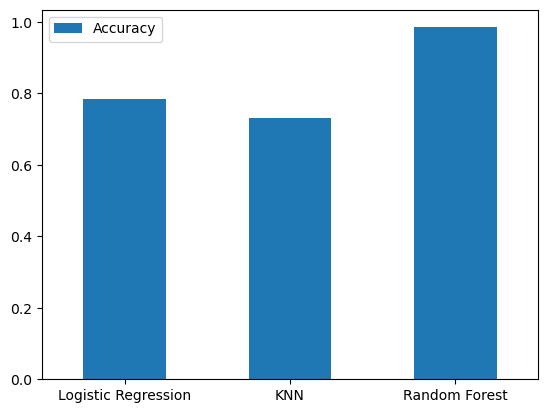

In [22]:
model_compare = pd.DataFrame(model_scores, index=["Accuracy"])
model_compare.T.plot(kind="bar")
plt.xticks(rotation=0)

In [23]:
train_scores = []
test_scores = []

#create a list for the different values of n_neigbor
neighbor = range(1, 21)

knn = KNeighborsClassifier()

for i in neighbor:
    knn.set_params(n_neighbors=i)

    #fit the data to the model
    knn.fit(X_train, y_train)

    #update the train score list
    train_scores.append(knn.score(X_train, y_train))

    #update the test score list
    test_scores.append(knn.score(X_test, y_test))


In [24]:
train_scores

[1.0,
 0.9963414634146341,
 0.9914634146341463,
 0.947560975609756,
 0.9231707317073171,
 0.8207317073170731,
 0.7914634146341464,
 0.7926829268292683,
 0.7670731707317073,
 0.7853658536585366,
 0.775609756097561,
 0.7695121951219512,
 0.7609756097560976,
 0.7817073170731708,
 0.7670731707317073,
 0.7670731707317073,
 0.75,
 0.7597560975609756,
 0.7634146341463415,
 0.7682926829268293]

In [25]:
test_scores

[0.9853658536585366,
 0.9560975609756097,
 0.9024390243902439,
 0.8097560975609757,
 0.7317073170731707,
 0.6878048780487804,
 0.6780487804878049,
 0.6682926829268293,
 0.7170731707317073,
 0.7170731707317073,
 0.6878048780487804,
 0.6780487804878049,
 0.6780487804878049,
 0.7170731707317073,
 0.7073170731707317,
 0.6926829268292682,
 0.6780487804878049,
 0.7073170731707317,
 0.7121951219512195,
 0.7170731707317073]

In [26]:
max(test_scores)

0.9853658536585366

In [1]:
# create a hyperparameter grid for logistic regression
log_reg_grid = {"C": np.logspace(-4, 4, 20),
                "solver": ["liblinear"]}

#create a hyperparameter grid for randomforest classifier
rf_grid = {"n_estimators": [100, 200, 300],
           "max_depth": [None, 3, 5],
           "min_samples_split": [2, 4, 6, 8],
           "min_samples_leaf": [1, 3, 5]
          }

NameError: name 'np' is not defined

In [28]:
#tume logistic regression model
np.random.seed(42)

#set up a hyperparameter for logistic regression
rs_log_reg = RandomizedSearchCV(LogisticRegression(),
                                param_distributions= log_reg_grid,
                                cv=5,
                                n_iter=20,
                                verbose=True)

#fit random hyperparameter search modelfor logistic regression
rs_log_reg.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,LogisticRegression()
,param_distributions,"{'C': array([1.0000...00000000e+04]), 'solver': ['liblinear']}"
,n_iter,20
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,True
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [29]:
rs_log_reg.best_params_

{'solver': 'liblinear', 'C': np.float64(1.623776739188721)}

In [30]:
rs_log_reg.score(X_test, y_test)

0.7853658536585366

In [31]:
# #tune randomclassifier model
# np.random.seed(42)

# #set up hyperparameter for randomforest
# rs_rf = RandomizedSearchCV(RandomForestClassifier(),
#                            param_distributions = rf_grid,
#                            cv=5,
#                            n_iter=20,
#                            verbose=True)

# #fit the tuned odel
# rs_rf.fit(X_train, y_train)

In [32]:
#rs_rf.best_params_

In [33]:
#rs_rf.score(X_test, y_test)

tuning the randomforest model further with gridsearch cv

In [34]:
gs_rf = GridSearchCV(RandomForestClassifier(),
                     param_grid = rf_grid,
                     cv=5, 
                     verbose=True)

#fit tuned model
gs_rf.fit(X_train, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


,estimator,RandomForestClassifier()
,param_grid,"{'max_depth': [None, 3, ...], 'min_samples_leaf': [1, 3, ...], 'min_samples_split': [2, 4, ...], 'n_estimators': array([100])}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,True
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,np.int64(100)


In [35]:
gs_rf.best_params_

{'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 4,
 'n_estimators': np.int64(100)}

In [36]:
gs_rf.score(X_test, y_test)

0.9853658536585366

## we ned to evaluate our tuned randomforest classifier beyond just accuracy

* AUC
* Classification report
* F1 score
* Confusion matrix
* ROC plot
* Precision

In [37]:
y_preds = gs_rf.predict(X_test)

In [38]:
y_preds

array([1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0,
       1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 0, 0])

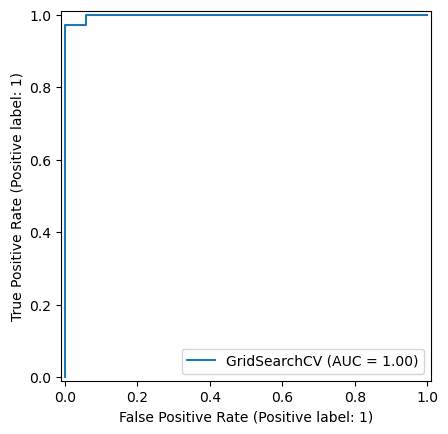

In [39]:
RocCurveDisplay.from_estimator(gs_rf, X_test, y_test)

In [40]:
#confusion matrix
print(confusion_matrix(y_test, y_preds))

[[102   0]
 [  3 100]]


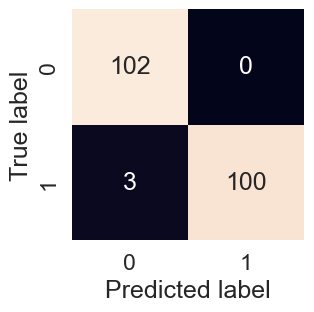

In [41]:
sns.set(font_scale=1.5)

def plot_conf_mat(y_test, y_preds):
    """
    Plots the confusion matrix using seaborn heatmap
    """
    fig, ax = plt.subplots(figsize=(3,3))
    ax = sns.heatmap(confusion_matrix(y_test, y_preds),
                     annot = True,
                     cbar = False,
                    fmt = "d")

    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    
plot_conf_mat(y_test, y_preds) 

In [42]:
#lets get the classification report of our model shall we
print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



In [43]:
#lets perform cross validation on the model
gs_rf.best_params_

{'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 4,
 'n_estimators': np.int64(100)}

In [44]:
clf1 = RandomForestClassifier(max_depth= None,
 min_samples_leaf= 1,
 min_samples_split= 4,
 n_estimators= np.int64(100))

In [45]:
evaluations = ["accuracy", "precision", "recall", "f1"]
overall = {}

def cross_val(evaluations, X, y):
    """
    This function uses cross evaluation to determine accuracy, precision, recall and f1score
    """
    for i in evaluations:
        metrics= cross_val_score(clf1,
                        X,
                        y,
                        cv=5,
                        scoring=i)

        overall[i] = np.mean(metrics)

    return overall

evaluation_metrics = cross_val(evaluations = evaluations,
                               X=X,
                               y=y)
      


In [46]:
evaluation_metrics

{'accuracy': np.float64(0.9970731707317073),
 'precision': np.float64(0.9944954128440366),
 'recall': np.float64(1.0),
 'f1': np.float64(0.9916537467700259)}

In [47]:
cv_metrics = pd.DataFrame(evaluation_metrics,
                         index=[0])
cv_metrics

,accuracy,precision,recall,f1
0,0.997073,0.994495,1.0,0.991654


(array([0, 1, 2, 3]),
 [Text(0, 0, 'accuracy'),
  Text(1, 0, 'precision'),
  Text(2, 0, 'recall'),
  Text(3, 0, 'f1')])

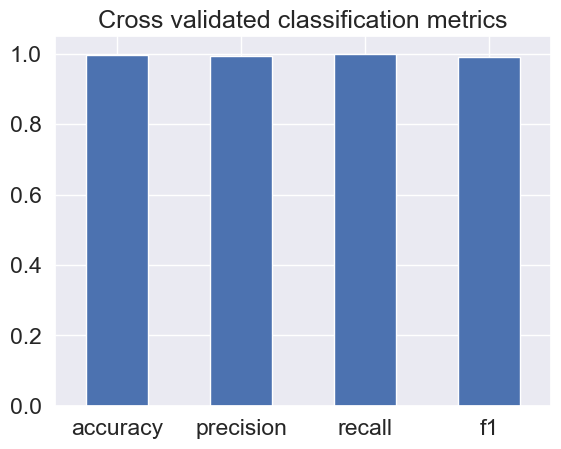

In [48]:
cv_metrics.T.plot.bar(title="Cross validated classification metrics",
                     legend=False)
plt.xticks(rotation=0)

## Feature importance

In [50]:
gs_rf.best_params_

{'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 4,
 'n_estimators': np.int64(100)}

In [55]:
clf2 = RandomForestClassifier(max_depth= None,
 min_samples_leaf= 1,
 min_samples_split= 4,
 n_estimators= np.int64(100))

clf2.fit(X_train, y_train)

,n_estimators,np.int64(100)
,criterion,'gini'
,max_depth,None
,min_samples_split,4
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [57]:
importances = clf2.feature_importances_
importances

array([0.07710479, 0.02557621, 0.13350229, 0.06803879, 0.07438109,
       0.00884043, 0.01832757, 0.12628649, 0.0616245 , 0.12008197,
       0.04371496, 0.12765891, 0.11486199])

In [60]:
feature_dict = dict(zip(df.columns, list(clf2.feature_importances_)))
feature_dict

{'age': np.float64(0.0771047923247888),
 'sex': np.float64(0.0255762121702981),
 'cp': np.float64(0.13350229447950065),
 'trestbps': np.float64(0.06803879135457484),
 'chol': np.float64(0.0743810912219612),
 'fbs': np.float64(0.008840427453247172),
 'restecg': np.float64(0.018327566432195307),
 'thalach': np.float64(0.12628649233138137),
 'exang': np.float64(0.061624503118447714),
 'oldpeak': np.float64(0.12008197481996503),
 'slope': np.float64(0.04371495544262709),
 'ca': np.float64(0.12765891186310732),
 'thal': np.float64(0.11486198698790552)}

In [63]:
feature_df = pd.DataFrame(feature_dict, index=[0])
feature_df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,0.077105,0.025576,0.133502,0.068039,0.074381,0.00884,0.018328,0.126286,0.061625,0.120082,0.043715,0.127659,0.114862


<Axes: title={'center': 'Feature importance of random forest model'}>

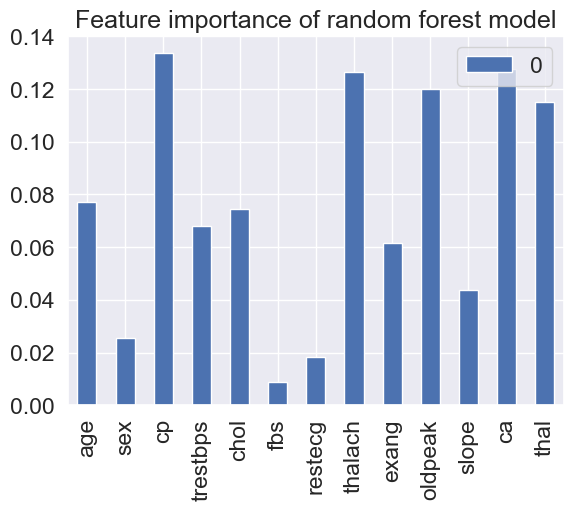

In [67]:
feature_df.T.plot.bar(title="Feature importance of random forest model")
